### Khang Tran Homework 04 Evaluation

In [30]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

df = pd.read_csv('https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv')
df

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1
...,...,...,...,...,...,...,...,...,...
1457,referral,manufacturing,1,NaN,self_employed,north_america,4,0.53,1
1458,referral,technology,3,65259.0,student,europe,2,0.24,1
1459,paid_ads,technology,1,45688.0,student,north_america,3,0.02,1
1460,referral,NaN,5,71016.0,self_employed,north_america,0,0.25,1


In [31]:
df.dtypes

lead_source                  object
industry                     object
number_of_courses_viewed      int64
annual_income               float64
employment_status            object
location                     object
interaction_count             int64
lead_score                  float64
converted                     int64
dtype: object

In [32]:
df.isnull().sum()

lead_source                 128
industry                    134
number_of_courses_viewed      0
annual_income               181
employment_status           100
location                     63
interaction_count             0
lead_score                    0
converted                     0
dtype: int64

In [33]:
categorical_feature = [i for i in df.columns if df[i].dtypes == 'object']
numerical_feature = [i for i in df.columns if df[i].dtypes != 'object' and i != 'converted']
df[categorical_feature] = df[categorical_feature].fillna('NA')
df[numerical_feature] = df[numerical_feature].fillna(0)

### Dataset preparation:

In [34]:
X = df.drop('converted',axis=1)
y = df['converted']
y

X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.25, random_state=1)

### Q1. ROC AUC Feature Importance:

ROC AUC could also be used to evaluate feature importance of numerical variables. 

Let's do that

* For each numerical variable, use it as score (aka prediction) and compute the AUC with the `y` variable as ground truth.
* Use the training dataset for that


If your AUC is < 0.5, invert this variable by putting "-" in front

(e.g. `-df_train['balance']`)

AUC can go below 0.5 if the variable is negatively correlated with the target variable. You can change the direction of the correlation by negating this variable - then negative correlation becomes positive.

Which numerical variable (among the following 4) has the highest AUC?

In [35]:
auc_values = {}

for col in numerical_feature:
    scores = X_train[col].values
    auc = roc_auc_score(y_train, scores)
    
    if auc < 0.5:
        auc = roc_auc_score(y_train, -scores)
    
    auc_values[col] = round(auc, 3)

# Show results
print("AUC by variable:")
for k, v in auc_values.items():
    print(f"{k:<10}: {v}")

# Find best variable
best_var = max(auc_values, key=auc_values.get)
print(f"\n✅ Best variable (highest AUC): {best_var} with AUC = {auc_values[best_var]}")

AUC by variable:
number_of_courses_viewed: 0.764
annual_income: 0.552
interaction_count: 0.738
lead_score: 0.614

✅ Best variable (highest AUC): number_of_courses_viewed with AUC = 0.764


### Q2. Training the model:

What's the AUC of this model on the validation dataset? (round to 3 digits)

In [36]:
# Convert your DataFrame rows into dictionaries
train_dicts = X_train.to_dict(orient='records')
val_dicts = X_val.to_dict(orient='records')
test_dicts = X_test.to_dict(orient='records')

# Initialize and fit the DictVectorizer
vec = DictVectorizer(sparse=True)

X_train = vec.fit_transform(train_dicts)
X_val = vec.transform(val_dicts)
X_test = vec.transform(test_dicts)

In [37]:
df[categorical_feature].nunique()

lead_source          6
industry             8
employment_status    5
location             8
dtype: int64

In [38]:
lr = LogisticRegression(solver = 'liblinear', C = 1.0, max_iter = 1000)
# lr = LogisticRegression(solver='lbfgs', C=1.0, max_iter = 1000)
lr.fit(X_train, y_train)
y_pred_val = lr.predict_proba(X_val)[:, 1]

# Compute AUC
round(roc_auc_score(y_val, y_pred_val),3)

np.float64(0.817)

### Q3. Precision and Recall:

Now let's compute precision and recall for our model.

* Evaluate the model on all thresholds from 0.0 to 1.0 with step 0.01
* For each threshold, compute precision and recall
* Plot them

At which threshold precision and recall curves intersect?

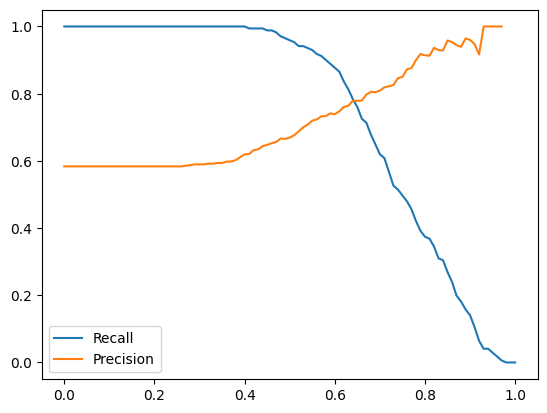

In [39]:
threshold_range = np.arange(0, 1.01, 0.01)
scores = []
precisions = []
recalls = []

for t in threshold_range:
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)
    
    predict_positive = (y_pred_val >= t)
    predict_negative = (y_pred_val < t)

    tp = (predict_positive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()

    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()
    
    # scores.append((t, tp, fp, fn, tn))
    scores.append((t, tp, tn, fp, fn))

# columns = ['threshold', 'tp', 'fp', 'fn', 'tn']
columns = ['threshold', 'tp','tn', 'fp', 'fn']
df_scores = pd.DataFrame(scores, columns=columns)

df_scores['tpr'] = df_scores['tp'] / (df_scores['tp'] + df_scores['fn'])
df_scores['fpr'] = df_scores['fp'] / (df_scores['fp'] + df_scores['tn'])
df_scores['Recall'] = df_scores['tpr']
df_scores['Precision'] = df_scores['tp'] / (df_scores['tp'] + df_scores['fp'])
df_scores['F1'] = (2 * df_scores['Precision'] * df_scores['Recall']) / (df_scores['Precision'] + df_scores['Recall'])
plt.plot(df_scores.threshold, df_scores['Recall'], label='Recall')
plt.plot(df_scores.threshold, df_scores['Precision'], label='Precision')
plt.legend()

In [44]:
diff = np.abs(df_scores['Precision'] - df_scores['Recall'])

# Find the index where the difference is minimal (i.e., where they intersect)
idx = diff.idxmin()

# Get the corresponding threshold and metric values
intersection_threshold = df_scores.loc[idx, 'threshold']
intersection_precision = df_scores.loc[idx, 'Precision']
intersection_recall = df_scores.loc[idx, 'Recall']

print(f"Intersection at threshold = {intersection_threshold:.2f}")
print(f"Precision = {intersection_precision:.3f}, Recall = {intersection_recall:.3f}")

Intersection at threshold = 0.64
Precision = 0.779, Recall = 0.784


### Q4. F1 Score:

Precision and recall are conflicting - when one grows, the other goes down. That's why they are often combined into the F1 score - a metrics that takes into account both

This is the formula for computing F1:

$$F_1 = 2 \cdot \cfrac{P \cdot R}{P + R}$$

Where $P$ is precision and $R$ is recall.

Let's compute F1 for all thresholds from 0.0 to 1.0 with increment 0.01

At which threshold F1 is maximal?

In [41]:
df_scores['Recall'] = df_scores['tpr']
df_scores['Precision'] = df_scores['tp'] / (df_scores['tp'] + df_scores['fp'])
df_scores['F1'] = (2 * df_scores['Precision'] * df_scores['Recall']) / (df_scores['Precision'] + df_scores['Recall'])
df_scores[['threshold','F1']].sort_values('F1',ascending=False)

,threshold,F1
57,0.57,0.812500
55,0.55,0.811224
56,0.56,0.809278
59,0.59,0.808511
58,0.58,0.808399
...,...,...
96,0.96,0.034483
97,0.97,0.011628
98,0.98,NaN
99,0.99,NaN


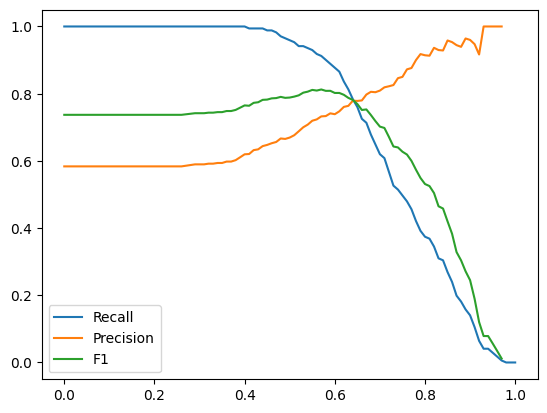

In [46]:
plt.plot(df_scores.threshold, df_scores['Recall'], label='Recall')
plt.plot(df_scores.threshold, df_scores['Precision'], label='Precision')
plt.plot(df_scores.threshold, df_scores['F1'], label='F1')
plt.legend()

In [47]:
idx_max_f1 = df_scores['F1'].idxmax()

# Extract the corresponding threshold and F1 value
best_threshold = df_scores.loc[idx_max_f1, 'threshold']
best_f1 = df_scores.loc[idx_max_f1, 'F1']

print(f"Best threshold for max F1 = {best_threshold:.2f}")
print(f"Maximum F1 score = {best_f1:.3f}")

Best threshold for max F1 = 0.57
Maximum F1 score = 0.812


### Q5. 5-Fold CV:

In [42]:
from sklearn.model_selection import KFold
df_full_train = X_trainval
kf = KFold(n_splits=5, shuffle=True, random_state=1)
auc_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(df_full_train, y_trainval)):
    print(f"\n--- Fold {fold+1} ---")
    
    train_df, val_df = df_full_train.iloc[train_idx], df_full_train.iloc[val_idx]
    y_train, y_val = y_trainval.iloc[train_idx], y_trainval.iloc[val_idx]
    
    train_dicts = train_df.to_dict(orient='records')
    val_dicts = val_df.to_dict(orient='records')

    # Initialize and fit the DictVectorizer
    vec = DictVectorizer(sparse=True)

    X_train_kf = vec.fit_transform(train_dicts)
    X_val_kf = vec.transform(val_dicts)
    print("Train shape:", X_train_kf.shape, " Validation shape:", X_val_kf.shape)
    print("Train y:", y_train.shape, " Validation y:", y_val.shape)

    model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
    model.fit(X_train_kf, y_train)
    y_val_pred_prob = model.predict_proba(X_val_kf)[:, 1]

    auc = roc_auc_score(y_val, y_val_pred_prob)
    auc_scores.append(auc)

    print(f"AUC for Fold {fold+1}: {auc:.4f}")

print()
print('std of AUC: {}'.format(np.std(auc_scores)))


--- Fold 1 ---
Train shape: (935, 31)  Validation shape: (234, 31)
Train y: (935,)  Validation y: (234,)
AUC for Fold 1: 0.8061

--- Fold 2 ---
Train shape: (935, 31)  Validation shape: (234, 31)
Train y: (935,)  Validation y: (234,)
AUC for Fold 2: 0.8714

--- Fold 3 ---
Train shape: (935, 31)  Validation shape: (234, 31)
Train y: (935,)  Validation y: (234,)
AUC for Fold 3: 0.7754

--- Fold 4 ---
Train shape: (935, 31)  Validation shape: (234, 31)
Train y: (935,)  Validation y: (234,)
AUC for Fold 4: 0.8018

--- Fold 5 ---
Train shape: (936, 31)  Validation shape: (233, 31)
Train y: (936,)  Validation y: (233,)
AUC for Fold 5: 0.8558

std of AUC: 0.03580711942905165


### Q6. Hyperparameter Tuning:

Now let's use 5-Fold cross-validation to find the best parameter `C`

* Iterate over the following `C` values: `[0.000001, 0.001, 1]`
* Initialize `KFold` with the same parameters as previously
* Use these parameters for the model: `LogisticRegression(solver='liblinear', C=C, max_iter=1000)`
* Compute the mean score as well as the std (round the mean and std to 3 decimal digits)

Which `C` leads to the best mean score?

In [43]:
from tqdm import tqdm
C_values = [0.000001, 0.001, 1]

# Prepare KFold
df_full_train = X_trainval
kf = KFold(n_splits=5, shuffle=True, random_state=1)

results = {}

# Outer loop over C values with tqdm
for C in tqdm(C_values, desc="Tuning C values"):
    auc_scores = []

    # Inner loop over folds with tqdm
    for fold, (train_idx, val_idx) in enumerate(tqdm(kf.split(df_full_train, y_trainval),
                                                     desc=f"C={C}", leave=False, total=kf.get_n_splits())):
        train_df, val_df = df_full_train.iloc[train_idx], df_full_train.iloc[val_idx]
        y_train, y_val = y_trainval.iloc[train_idx], y_trainval.iloc[val_idx]

        # Convert to dictionaries
        train_dicts = train_df.to_dict(orient='records')
        val_dicts = val_df.to_dict(orient='records')

        # Vectorize
        vec = DictVectorizer(sparse=True)
        X_train_kf = vec.fit_transform(train_dicts)
        X_val_kf = vec.transform(val_dicts)

        # Train Logistic Regression
        model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
        model.fit(X_train_kf, y_train)

        # Predict and evaluate
        y_val_pred_prob = model.predict_proba(X_val_kf)[:, 1]
        auc = roc_auc_score(y_val, y_val_pred_prob)
        auc_scores.append(auc)

    # Compute mean and std of AUC
    mean_auc = round(np.mean(auc_scores), 3)
    std_auc = round(np.std(auc_scores), 3)
    results[C] = (mean_auc, std_auc)

# Print summary
print("\n=== Summary of Results ===")
print("C-value     Mean AUC     Std AUC")
for C, (mean_auc, std_auc) in results.items():
    print(f"{C:<10} {mean_auc:<12} {std_auc}")

# Find best C
best_C = max(results, key=lambda c: results[c][0])
print(f"\nBest C value (highest mean AUC): {best_C}")

Tuning C values:  67%|██████▋   | 2/3 [00:00<00:00,  8.39it/s]

Tuning C values: 100%|██████████| 3/3 [00:00<00:00,  8.01it/s]


=== Summary of Results ===
C-value     Mean AUC     Std AUC
1e-06      0.56         0.024
0.001      0.867        0.029
1          0.822        0.036

Best C value (highest mean AUC): 0.001
